In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from dnsmex.local import localify
from utils import is_in_cdr, sort_antibody_sites, GERMLINE_PATH_DICTIONARY, add_cdr_shading
from dnsmex.koenig_helper import KoenigDataset



In [2]:
# koenig concensus seq, IGHV3
koenig_anarci_chothia = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/koenig/koenig_concensus_anarci_output_H_chothia.csv')
koenig_anarci_chothia = koenig_anarci_chothia.T

# Find the position where index equals 1
start_pos = koenig_anarci_chothia.index.get_loc('1')

# Keep everything from that position onward
koenig_anarci_chothia = koenig_anarci_chothia.iloc[start_pos:]

koenig_anarci_chothia = koenig_anarci_chothia.reset_index()
koenig_anarci_chothia.index = koenig_anarci_chothia.index + 1
koenig_anarci_chothia.rename(columns={'index': 'chothia_site'}, inplace=True)
koenig_anarci_chothia.drop(columns=[0], inplace=True)
koenig_anarci_chothia = koenig_anarci_chothia.reset_index()
koenig_anarci_chothia.rename(columns={'index': 'koenig_index'}, inplace=True)
koenig_anarci_chothia

,koenig_index,chothia_site
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
...,...,...
115,116,109
116,117,110
117,118,111
118,119,112


In [3]:
## with Koenig dataframe


binding_dataset = KoenigDataset(
    localify("DATA_DIR/FLAb/data/binding/Koenig2017_g6_Kd.csv"),
    fitness_column="fitness",
    fitness_label="binding enrichment ratio",
    log_transform=True,
)

expr_dataset = KoenigDataset(
    localify("DATA_DIR/FLAb/data/expression/Koenig2017_g6_er.csv"), 
    fitness_column="fitness",
    fitness_label="binding enrichment ratio",
    log_transform=True,
    )

binding_df = pd.merge(binding_dataset.heavy_df, koenig_anarci_chothia.rename(columns={'koenig_index':'site'}), on='site')
expression_df = pd.merge(expr_dataset.heavy_df, koenig_anarci_chothia.rename(columns={'koenig_index':'site'}), on='site')

binding_df['log_fitness'] = np.log(binding_df.fitness)
expression_df['log_fitness'] = np.log(expression_df.fitness)



In [4]:
## aggregate fitness per site, as the mutations present do not show all entrenched possibilities

In [5]:
fitness_df = pd.merge(binding_df.groupby('chothia_site').log_fitness.mean().reset_index(), expression_df.groupby('chothia_site').log_fitness.mean().reset_index(), on='chothia_site', suffixes=('_binding', '_expression'))
fitness_df

,chothia_site,log_fitness_binding,log_fitness_expression
0,10,-0.327888,0.229007
1,100,-2.138957,-1.320900
2,100A,-1.225351,-0.134102
3,100B,-3.666193,-0.469191
4,100C,-0.976824,-0.264573
...,...,...,...
114,95,-3.198672,-0.284015
115,96,-2.844174,-0.239277
116,97,-1.902043,0.065033
117,98,-3.472526,0.188595


In [6]:
entrenched_within = pd.read_csv('_output/entrenchment_analysis/chothia/entrenched_aa_sites_within_IGHV3.csv', dtype={'site':str})
entrenched_between = pd.read_csv('_output/entrenchment_analysis/chothia/entrenched_aa_sites_IGHV1_vs_IGHV3.csv', dtype={'site':str})    
entrenched_between = entrenched_between[entrenched_between['v_family']=='IGHV3']


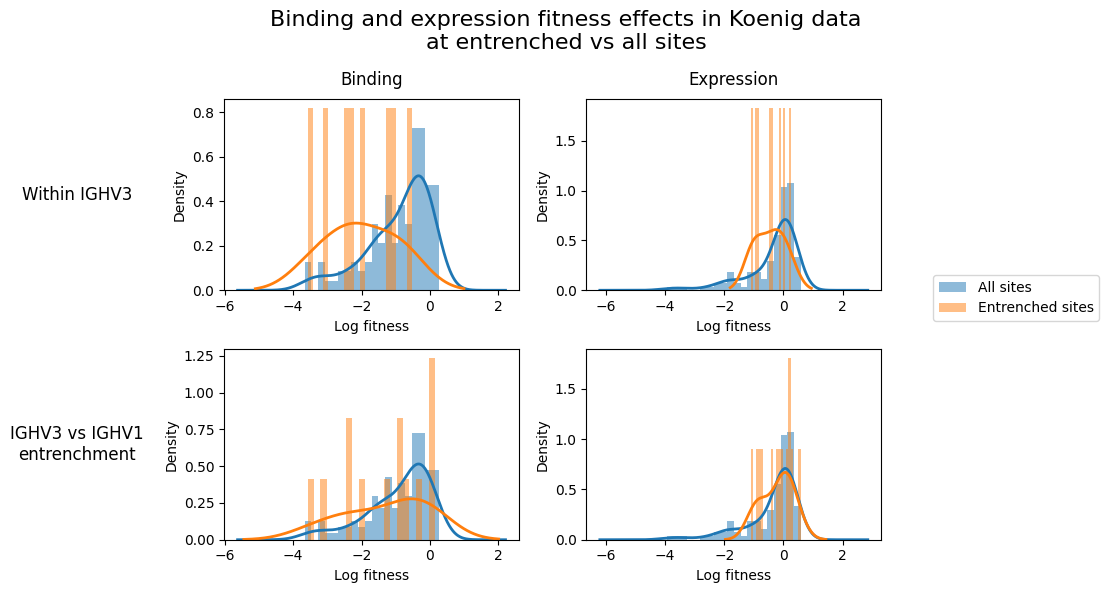

In [7]:
# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Get first two colors from tab20
colors = plt.cm.tab10.colors
color_all = colors[0]
color_entrenched = colors[1]

# Row 1: Within IGHV3 entrenched
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_within.site)]

# Binding fitness
fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_entrenched, legend=False)
axes[0,0].set_xlabel('Log fitness')
axes[0,0].set_ylabel('Density')

# Expression fitness
fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_entrenched, legend=False)
axes[0,1].set_xlabel('Log fitness')
axes[0,1].set_ylabel('Density')

# Row 2: Between IGHV1 and IGHV3
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_between.site)]
#entrenched_fitness_df = fitness_df[(fitness_df.chothia_site.isin(entrenched_between.site)) & (~fitness_df.chothia_site.isin(entrenched_within.site))]


# Binding fitness
fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_entrenched, legend=False)
axes[1,0].set_xlabel('Log fitness')
axes[1,0].set_ylabel('Density')

# Expression fitness
fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_entrenched, legend=False)
axes[1,1].set_xlabel('Log fitness')
axes[1,1].set_ylabel('Density')

# Column titles
axes[0,0].set_title('Binding', fontsize=12, pad=10)
axes[0,1].set_title('Expression', fontsize=12, pad=10)

# Row titles (on the left side, horizontal)
axes[0,0].text(-0.5, 0.5, 'Within IGHV3', transform=axes[0,0].transAxes, 
               fontsize=12, va='center', ha='center')
axes[1,0].text(-0.5, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1,0].transAxes, 
               fontsize=12, va='center', ha='center')

# Get only histogram handles (first 2) from legend
handles, labels = axes[0,0].get_legend_handles_labels()
legend = fig.legend(handles[:2], labels[:2], loc='center left', bbox_to_anchor=(0.9, 0.5))

# Remove individual legends
for ax_row in axes:
    for ax in ax_row:
        if ax.get_legend():
            ax.legend().remove()

fig.suptitle('Binding and expression fitness effects in Koenig data\nat entrenched vs all sites', fontsize=16)
plt.tight_layout()
fig.subplots_adjust(left=0.12, right=0.85)  # Make room for row titles and legend
fig.show()
fig.savefig('figures/koenig_binding_expression_fitness_entrenchment_histograms.png', dpi=800, bbox_inches='tight')


Statistical test results (Mann-Whitney U test):
Within V family - Binding: p = 4.75e-03, r = -0.599
Within V family - Expression: p = 2.13e-01, r = -0.265
Between V families - Binding: p = 3.19e-01, r = -0.169
Between V families - Expression: p = 9.24e-01, r = 0.017


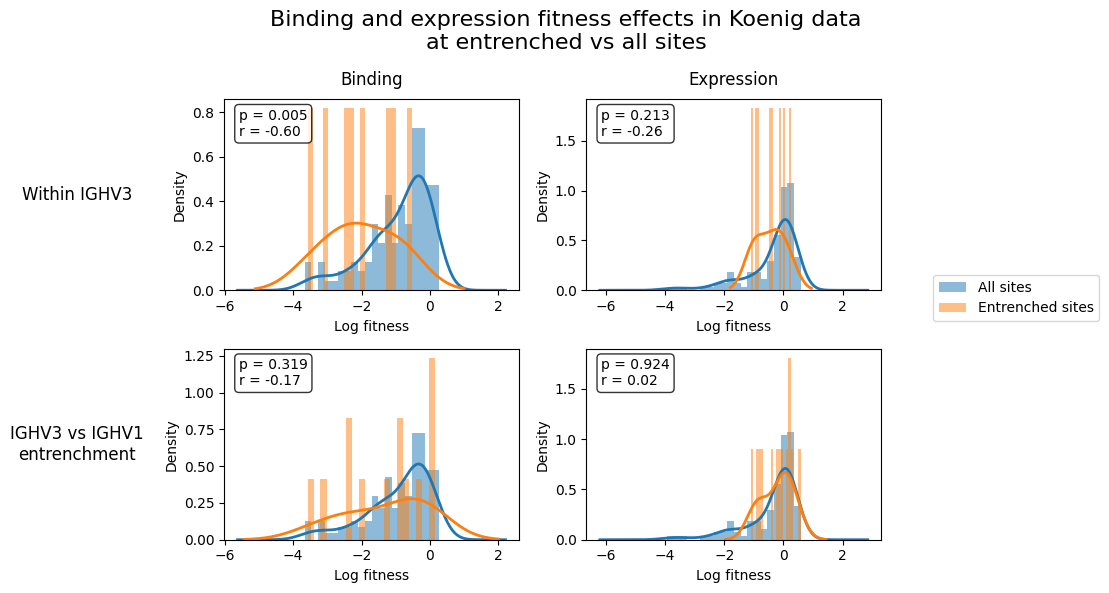

In [8]:
from scipy.stats import mannwhitneyu, ks_2samp
import numpy as np

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# Get first two colors from tab20
colors = plt.cm.tab10.colors
color_all = colors[0]
color_entrenched = colors[1]

# Row 1: Within IGHV3 entrenched
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_within.site)]

# Binding fitness
fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_entrenched, legend=False)
axes[0,0].set_xlabel('Log fitness')
axes[0,0].set_ylabel('Density')

# Statistical test - binding (within)
stat_binding_within, p_binding_within = mannwhitneyu(
    fitness_df.log_fitness_binding.dropna(), 
    entrenched_fitness_df.log_fitness_binding.dropna(),
    alternative='two-sided'
)
# Calculate effect size
n1 = len(fitness_df.log_fitness_binding.dropna())
n2 = len(entrenched_fitness_df.log_fitness_binding.dropna())
r_binding_within = 1 - (2*stat_binding_within) / (n1 * n2)

# Add p-value and effect size to plot
p_text = f'p = {p_binding_within:.2e}' if p_binding_within < 0.001 else f'p = {p_binding_within:.3f}'
effect_text = f'r = {r_binding_within:.2f}'
combined_text = f'{p_text}\n{effect_text}'
axes[0,0].text(0.05, 0.95, combined_text, transform=axes[0,0].transAxes, 
               fontsize=10, va='top', ha='left', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Expression fitness
fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_entrenched, legend=False)
axes[0,1].set_xlabel('Log fitness')
axes[0,1].set_ylabel('Density')

# Statistical test - expression (within)
stat_expr_within, p_expr_within = mannwhitneyu(
    fitness_df.log_fitness_expression.dropna(), 
    entrenched_fitness_df.log_fitness_expression.dropna(),
    alternative='two-sided'
)
n1 = len(fitness_df.log_fitness_expression.dropna())
n2 = len(entrenched_fitness_df.log_fitness_expression.dropna())
r_expr_within = 1 - (2*stat_expr_within) / (n1 * n2)

p_text = f'p = {p_expr_within:.2e}' if p_expr_within < 0.001 else f'p = {p_expr_within:.3f}'
effect_text = f'r = {r_expr_within:.2f}'
combined_text = f'{p_text}\n{effect_text}'
axes[0,1].text(0.05, 0.95, combined_text, transform=axes[0,1].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Row 2: Between IGHV1 and IGHV3
entrenched_fitness_df = fitness_df[fitness_df.chothia_site.isin(entrenched_between.site)]

# Binding fitness
fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_entrenched, legend=False)
axes[1,0].set_xlabel('Log fitness')
axes[1,0].set_ylabel('Density')

# Statistical test - binding (between)
stat_binding_between, p_binding_between = mannwhitneyu(
    fitness_df.log_fitness_binding.dropna(), 
    entrenched_fitness_df.log_fitness_binding.dropna(),
    alternative='two-sided'
)
n1 = len(fitness_df.log_fitness_binding.dropna())
n2 = len(entrenched_fitness_df.log_fitness_binding.dropna())
r_binding_between = 1 - (2*stat_binding_between) / (n1 * n2)

p_text = f'p = {p_binding_between:.2e}' if p_binding_between < 0.001 else f'p = {p_binding_between:.3f}'
effect_text = f'r = {r_binding_between:.2f}'
combined_text = f'{p_text}\n{effect_text}'
axes[1,0].text(0.05, 0.95, combined_text, transform=axes[1,0].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Expression fitness
fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_entrenched, legend=False)
axes[1,1].set_xlabel('Log fitness')
axes[1,1].set_ylabel('Density')

# Statistical test - expression (between)
stat_expr_between, p_expr_between = mannwhitneyu(
    fitness_df.log_fitness_expression.dropna(), 
    entrenched_fitness_df.log_fitness_expression.dropna(),
    alternative='two-sided'
)
n1 = len(fitness_df.log_fitness_expression.dropna())
n2 = len(entrenched_fitness_df.log_fitness_expression.dropna())
r_expr_between = 1 - (2*stat_expr_between) / (n1 * n2)

p_text = f'p = {p_expr_between:.2e}' if p_expr_between < 0.001 else f'p = {p_expr_between:.3f}'
effect_text = f'r = {r_expr_between:.2f}'
combined_text = f'{p_text}\n{effect_text}'
axes[1,1].text(0.05, 0.95, combined_text, transform=axes[1,1].transAxes, 
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Column titles
axes[0,0].set_title('Binding', fontsize=12, pad=10)
axes[0,1].set_title('Expression', fontsize=12, pad=10)

# Row titles (on the left side, horizontal)
axes[0,0].text(-0.5, 0.5, 'Within IGHV3', transform=axes[0,0].transAxes, 
               fontsize=12, va='center', ha='center')
axes[1,0].text(-0.5, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1,0].transAxes, 
               fontsize=12, va='center', ha='center')

# Get only histogram handles (first 2) from legend
handles, labels = axes[0,0].get_legend_handles_labels()
legend = fig.legend(handles[:2], labels[:2], loc='center left', bbox_to_anchor=(0.9, 0.5))

# Remove individual legends
for ax_row in axes:
    for ax in ax_row:
        if ax.get_legend():
            ax.legend().remove()

fig.suptitle('Binding and expression fitness effects in Koenig data\nat entrenched vs all sites', fontsize=16)
plt.tight_layout()
fig.subplots_adjust(left=0.12, right=0.85)  # Make room for row titles and legend

# Print summary of statistical tests
print("\nStatistical test results (Mann-Whitney U test):")
print(f"Within V family - Binding: p = {p_binding_within:.2e}, r = {r_binding_within:.3f}")
print(f"Within V family - Expression: p = {p_expr_within:.2e}, r = {r_expr_within:.3f}")
print(f"Between V families - Binding: p = {p_binding_between:.2e}, r = {r_binding_between:.3f}")
print(f"Between V families - Expression: p = {p_expr_between:.2e}, r = {r_expr_between:.3f}")

fig.show()
fig.savefig('figures/koenig_binding_expression_fitness_entrenchment_histograms.png', dpi=800, bbox_inches='tight')

In [9]:
### individual mutations

fitness_df = pd.merge(binding_df, expression_df, on=['chothia_site', 'site', 'difference', 'aa'], suffixes=('_binding', '_expression'))


In [10]:
fitness_df['amino_acid'] = fitness_df.difference.str[0]
fitness_df.rename(columns={'aa':'target_amino_acid'}, inplace=True)
fitness_df

,heavy_binding,light_binding,fitness_binding,heavy_differences_binding,light_differences_binding,heavy_difference_count_binding,light_difference_count_binding,difference_count_binding,difference,site,...,heavy_expression,light_expression,fitness_expression,heavy_differences_expression,light_differences_expression,heavy_difference_count_expression,light_difference_count_expression,difference_count_expression,log_fitness_expression,amino_acid
0,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,3.620218,[V2A],[],1,0,1,V2A,2,...,EAQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.819679,[V2A],[],1,0,1,-0.198843,V
1,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.142127,[V2C],[],1,0,1,V2C,2,...,ECQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.328397,[V2C],[],1,0,1,-1.113532,V
2,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.378990,[V2D],[],1,0,1,V2D,2,...,EDQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.585834,[V2D],[],1,0,1,0.461110,V
3,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.578943,[V2E],[],1,0,1,V2E,2,...,EEQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.806183,[V2E],[],1,0,1,0.591216,V
4,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.806596,[V2F],[],1,0,1,V2F,2,...,EFQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.452152,[V2F],[],1,0,1,0.373046,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,2.324930,[S120R],[],1,0,1,S120R,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.780243,[S120R],[],1,0,1,0.576750,S
2257,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.376044,[S120T],[],1,0,1,S120T,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.461977,[S120T],[],1,0,1,0.379790,S
2258,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.835231,[S120V],[],1,0,1,S120V,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.177392,[S120V],[],1,0,1,0.163302,S
2259,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.326943,[S120W],[],1,0,1,S120W,120,...,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.129685,[S120W],[],1,0,1,0.121939,S


In [11]:
pd.merge(fitness_df, entrenched_within.rename(columns={'site':'chothia_site'}), on=['chothia_site', 'amino_acid', 'target_amino_acid'])

,heavy_binding,light_binding,fitness_binding,heavy_differences_binding,light_differences_binding,heavy_difference_count_binding,light_difference_count_binding,difference_count_binding,difference,site,...,light_expression,fitness_expression,heavy_differences_expression,light_differences_expression,heavy_difference_count_expression,light_difference_count_expression,difference_count_expression,log_fitness_expression,amino_acid,v_family
0,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIDWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.261539,[H35D],[],1,0,1,H35D,35,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.384806,[H35D],[],1,0,1,0.325560,H,IGHV3
1,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWFRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.223289,[V37F],[],1,0,1,V37F,37,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.688665,[V37F],[],1,0,1,-0.373001,V,IGHV3
2,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.089705,[G50R],[],1,0,1,G50R,50,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.708237,[G50R],[],1,0,1,-0.344977,G,IGHV3
3,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.068645,[R98T],[],1,0,1,R98T,98,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.675957,[R98T],[],1,0,1,-0.391625,R,IGHV3


In [12]:
pd.merge(fitness_df, entrenched_between.rename(columns={'site':'chothia_site'}), on=['chothia_site', 'amino_acid', 'target_amino_acid'])

,heavy_binding,light_binding,fitness_binding,heavy_differences_binding,light_differences_binding,heavy_difference_count_binding,light_difference_count_binding,difference_count_binding,difference,site,...,light_expression,fitness_expression,heavy_differences_expression,light_differences_expression,heavy_difference_count_expression,light_difference_count_expression,difference_count_expression,log_fitness_expression,amino_acid,v_family
0,EVQLVESGAGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.946792,[G9A],[],1,0,1,G9A,9,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.117402,[G9A],[],1,0,1,0.111007,G,IGHV3
1,EVQLVESGGGLVQPGASLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.833993,[G16A],[],1,0,1,G16A,16,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.799102,[G16A],[],1,0,1,0.587288,G,IGHV3
2,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQARGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,4.609037,[P41R],[],1,0,1,P41R,41,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.039766,[P41R],[],1,0,1,0.038995,P,IGHV3
3,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.089705,[G50R],[],1,0,1,G50R,50,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.708237,[G50R],[],1,0,1,-0.344977,G,IGHV3
4,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.180493,[I51F],[],1,0,1,I51F,51,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.199980,[I51F],[],1,0,1,0.182305,I,IGHV3
5,EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,0.854299,[K76T],[],1,0,1,K76T,76,...,DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKL...,1.333642,[K76T],[],1,0,1,0.287914,K,IGHV3


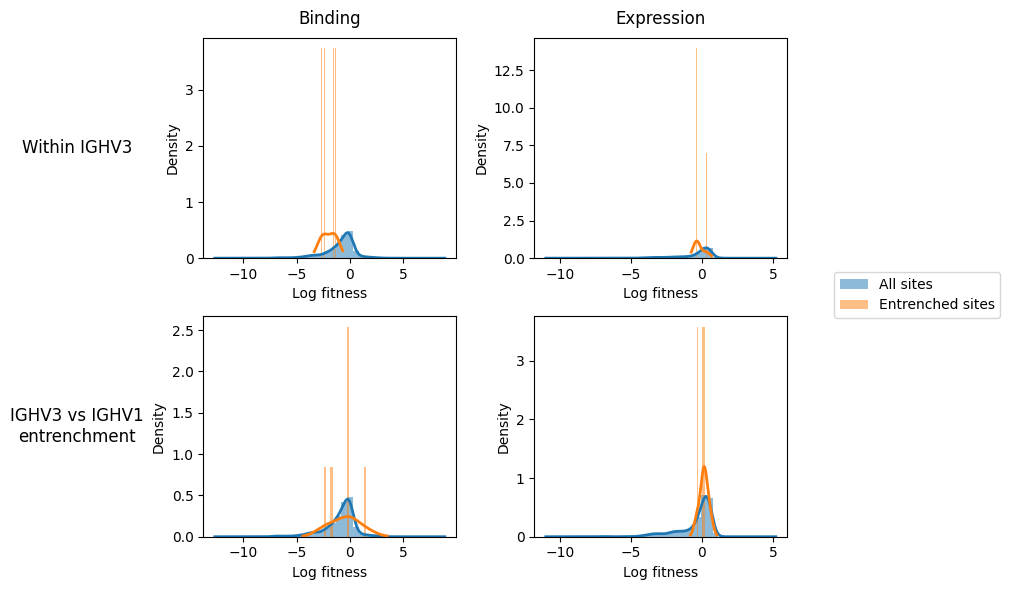

In [13]:
# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Get first two colors from tab20
colors = plt.cm.tab10.colors
color_all = colors[0]
color_entrenched = colors[1]

# Row 1: Within IGHV3 entrenched
entrenched_fitness_df = pd.merge(fitness_df, entrenched_within.rename(columns={'site':'chothia_site'}), on=['chothia_site', 'amino_acid', 'target_amino_acid'])

# Binding fitness
fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[0,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[0,0], linewidth=2, color=color_entrenched, legend=False)
axes[0,0].set_xlabel('Log fitness')
axes[0,0].set_ylabel('Density')

# Expression fitness
fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[0,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[0,1], linewidth=2, color=color_entrenched, legend=False)
axes[0,1].set_xlabel('Log fitness')
axes[0,1].set_ylabel('Density')

# Row 2: Between IGHV1 and IGHV3
entrenched_fitness_df = pd.merge(fitness_df, entrenched_between.rename(columns={'site':'chothia_site'}), on=['chothia_site', 'amino_acid', 'target_amino_acid'])
#entrenched_fitness_df = fitness_df[(fitness_df.chothia_site.isin(entrenched_between.site)) & (~fitness_df.chothia_site.isin(entrenched_within.site))]


# Binding fitness
fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_binding.hist(bins=20, ax=axes[1,0], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_binding.plot.kde(ax=axes[1,0], linewidth=2, color=color_entrenched, legend=False)
axes[1,0].set_xlabel('Log fitness')
axes[1,0].set_ylabel('Density')

# Expression fitness
fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='All sites', density=True, color=color_all)
entrenched_fitness_df.log_fitness_expression.hist(bins=20, ax=axes[1,1], alpha=0.5, label='Entrenched sites', density=True, color=color_entrenched)
fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_all, legend=False)
entrenched_fitness_df.log_fitness_expression.plot.kde(ax=axes[1,1], linewidth=2, color=color_entrenched, legend=False)
axes[1,1].set_xlabel('Log fitness')
axes[1,1].set_ylabel('Density')

# Column titles
axes[0,0].set_title('Binding', fontsize=12, pad=10)
axes[0,1].set_title('Expression', fontsize=12, pad=10)

# Row titles (on the left side, horizontal)
axes[0,0].text(-0.5, 0.5, 'Within IGHV3', transform=axes[0,0].transAxes, 
               fontsize=12, va='center', ha='center')
axes[1,0].text(-0.5, 0.5, 'IGHV3 vs IGHV1\nentrenchment', transform=axes[1,0].transAxes, 
               fontsize=12, va='center', ha='center')

# Get only histogram handles (first 2) from legend
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='center left', bbox_to_anchor=(0.9, 0.5))

# Remove individual legends
for ax_row in axes:
    for ax in ax_row:
        if ax.get_legend():
            ax.legend().remove()

plt.tight_layout()
fig.subplots_adjust(left=0.12, right=0.85)  # Make room for row titles and legend
fig.show()